# BanglaGSG Training Telemetry
This notebook visualizes the training progress from `metrics.csv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plotting style
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load metrics
metrics_path = "../saved/logs/metrics.csv"

if os.path.exists(metrics_path):
    df = pd.read_csv(metrics_path)
    print(f"Loaded {len(df)} training steps.")
    display(df.tail())
else:
    print(f"Metrics file not found at {metrics_path}. Make sure training has started!")

Loaded 3671 training steps.


,step,tokens_seen,epoch_frac,loss,perplexity,z_loss,lr_muon,lr_adamw,grad_norm_muon,grad_norm_adamw,gdn_grad_norm,swa_grad_norm,gqa_grad_norm,tokens_per_sec,gpu_mem_mb,peak_gpu_mem_mb,elapsed_s
3666,36670,9608126720,0.99880,2.87877,17.663,0.007314,0.002,0.00003,0.132159,0.144033,0.112113,0.0,0.0,21992.8,1996.4,10267.7,453186.1
3667,36680,9610746880,0.99907,2.82234,16.696,0.007184,0.002,0.00003,0.127580,0.175940,0.155641,0.0,0.0,21981.3,1996.4,10267.7,453305.1
3668,36690,9613367040,0.99935,2.76546,15.776,0.006942,0.002,0.00003,0.123918,0.165796,0.142116,0.0,0.0,21988.3,1996.4,10267.7,453424.2
3669,36700,9615987200,0.99962,2.65877,14.180,0.006945,0.002,0.00003,0.139794,0.157447,0.138020,0.0,0.0,21992.2,1996.4,10267.7,453543.3
3670,36710,9618607360,0.99989,2.83358,16.885,0.007165,0.002,0.00003,0.127651,0.176357,0.153873,0.0,0.0,21990.4,1996.4,10267.7,453662.3


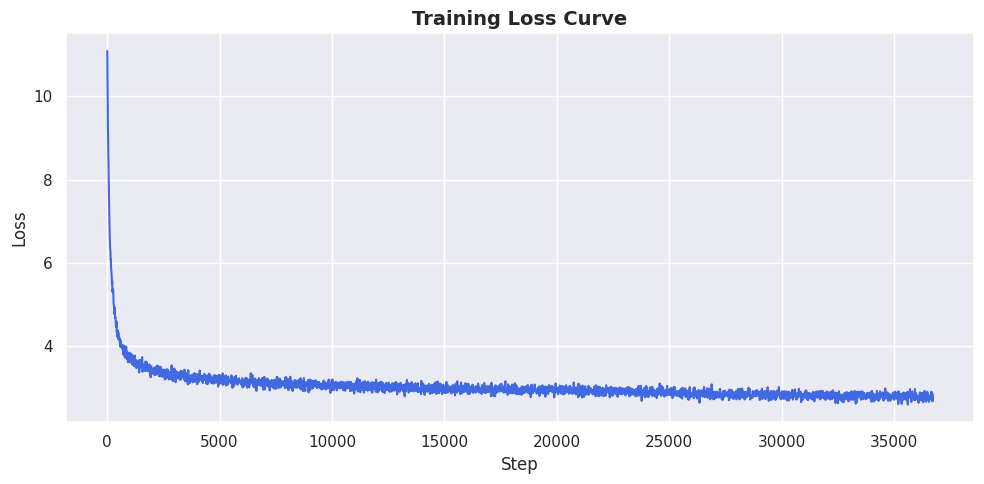

In [3]:
# Plot Training Loss vs Step
if 'step' in df.columns and 'loss' in df.columns:
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=df, x='step', y='loss', color='royalblue', linewidth=1.5)
    plt.title("Training Loss Curve", fontsize=14, fontweight='bold')
    plt.xlabel("Step", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.tight_layout()
    plt.show()

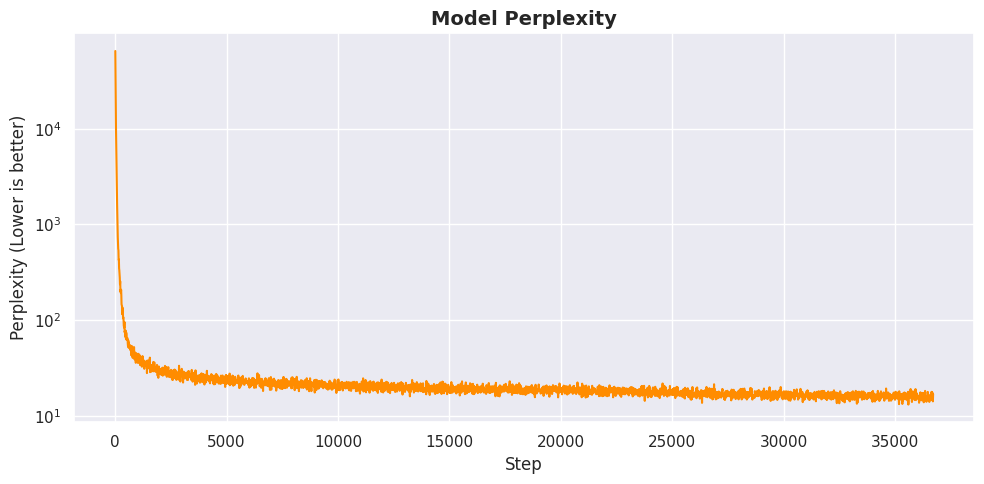

In [4]:
# Plot Perplexity
if 'step' in df.columns and 'perplexity' in df.columns:
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=df, x='step', y='perplexity', color='darkorange', linewidth=1.5)
    plt.title("Model Perplexity", fontsize=14, fontweight='bold')
    plt.xlabel("Step", fontsize=12)
    plt.ylabel("Perplexity (Lower is better)", fontsize=12)
    # Cap Y axis if perplexity explodes early on
    plt.yscale("log")
    # Added log scale to see the actual progress!
    plt.tight_layout()
    plt.show()

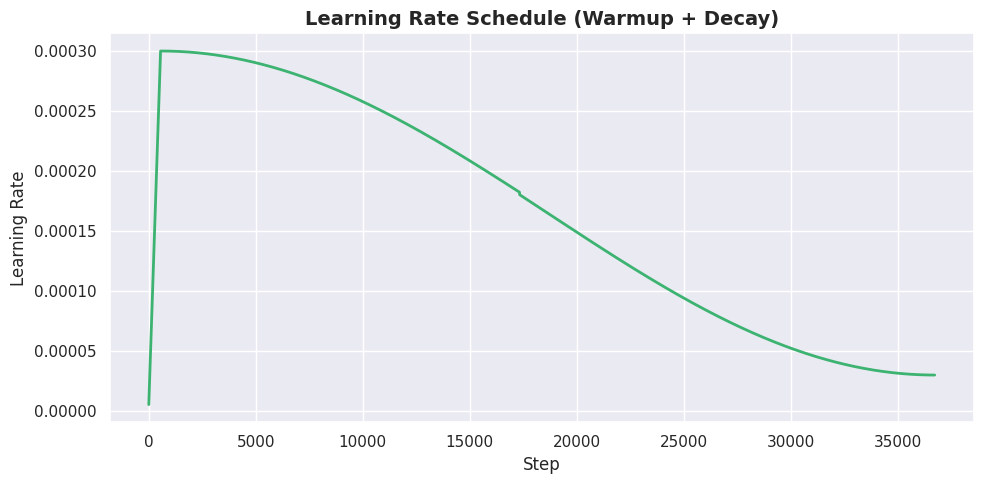

In [5]:
# Plot Learning Rate Schedule
if 'step' in df.columns and 'lr_adamw' in df.columns:
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=df, x='step', y='lr_adamw', color='mediumseagreen', linewidth=2)
    plt.title("Learning Rate Schedule (Warmup + Decay)", fontsize=14, fontweight='bold')
    plt.xlabel("Step", fontsize=12)
    plt.ylabel("Learning Rate", fontsize=12)
    plt.tight_layout()
    plt.show()